In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Download the lexicon (needed for VADER)
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [24]:
import pandas as pd
import os
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# 1. Technical Indicator Logic (Task 2)
def get_technical_indicators(df):
    df = df.copy()
    df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
    df = df.dropna(subset=['Close'])
    
    # EMA & MACD (What the reviewer asked for)
    df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()
    ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema_12 - ema_26
    
    # Returns (Replaces broken pynance)
    df['Daily_Returns'] = df['Close'].pct_change()
    return df

# 2. Sentiment Logic (Task 3)
def get_sentiment(df):
    df = df.copy()
    analyzer = SentimentIntensityAnalyzer()
    # Making sure we use the right column name from your news file
    df['sentiment_score'] = df['headline'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])
    return df

In [8]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'EDA_News.ipynb', 'README.md', 'Task_3_Correlation_Analysis.ipynb', '__init__.py']


In [30]:
import pandas as pd
import os
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# 1. SET PATHS
stock_path = '../data/raw/AAPL.csv'
news_path = '../data/raw/raw_analyst_ratings.csv'

try:
    # 2. LOAD DATA FRESH
    stock_df = pd.read_csv(stock_path)
    news_df = pd.read_csv(news_path)
    
    # 3. STANDARDIZE COLUMN NAMES
    stock_df.columns = stock_df.columns.str.strip().str.lower()
    news_df.columns = news_df.columns.str.strip().str.lower()
    
    # 4. RE-STABLISH THE DATE COLUMN (This was the missing index!)
    # We will look for any column that looks like a date in the raw file
    if 'date' not in stock_df.columns:
        # Sometimes the first column is the date but has no name or is called 'unnamed: 0'
        stock_df.rename(columns={stock_df.columns[0]: 'date'}, inplace=True)
    
    # 5. FIX NUMERIC DATA
    stock_df['close'] = pd.to_numeric(stock_df['close'], errors='coerce')
    stock_df = stock_df.dropna(subset=['close', 'date']) # Ensure we have both
    
    # Calculate Indicators
    stock_df['ema_20'] = stock_df['close'].ewm(span=20, adjust=False).mean()
    ema_12 = stock_df['close'].ewm(span=12, adjust=False).mean()
    ema_26 = stock_df['close'].ewm(span=26, adjust=False).mean()
    stock_df['macd'] = ema_12 - ema_26
    stock_df['daily_returns'] = stock_df['close'].pct_change()
    
    # 6. SENTIMENT ANALYSIS
    analyzer = SentimentIntensityAnalyzer()
    print("Analyzing sentiment... (this may take a moment)")
    news_df['sentiment_score'] = news_df['headline'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])
    
    # 7. CONVERT DATES AND MERGE
    stock_df['date'] = pd.to_datetime(stock_df['date'], errors='coerce').dt.date
    news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce').dt.date
    
    merged = pd.merge(news_df, stock_df, on='date')
    
    # 8. OUTPUT RESULTS
    print("\n✅ ANALYSIS COMPLETE")
    print("\n--- TASK 2: TECHNICAL INDICATORS (AAPL) ---")
    print(stock_df[['date', 'close', 'ema_20', 'macd']].head())
    
    if not merged.empty:
        correlation = merged['sentiment_score'].corr(merged['daily_returns'])
        print(f"\n--- TASK 3: FINAL CORRELATION ---\nResult: {correlation:.4f}")
    else:
        print("\n⚠️ No overlapping dates found. Check if stock and news data cover the same time period.")

except Exception as e:
    print(f"❌ ERROR ENCOUNTERED: {e}")

Analyzing sentiment... (this may take a moment)

✅ ANALYSIS COMPLETE

--- TASK 2: TECHNICAL INDICATORS (AAPL) ---
         date      close     ema_20      macd
2  2020-01-02  72.400505  72.400505  0.000000
3  2020-01-03  71.696663  72.333472 -0.056147
4  2020-01-06  72.267937  72.327231 -0.053925
5  2020-01-07  71.928032  72.289212 -0.078685
6  2020-01-08  73.085114  72.365012 -0.004884

--- TASK 3: FINAL CORRELATION ---
Result: 0.1776


In [32]:
print(stock_df.columns.tolist())

['date', 'date', 'close', 'high', 'low', 'open', 'volume', 'ema_20', 'macd', 'daily_returns']


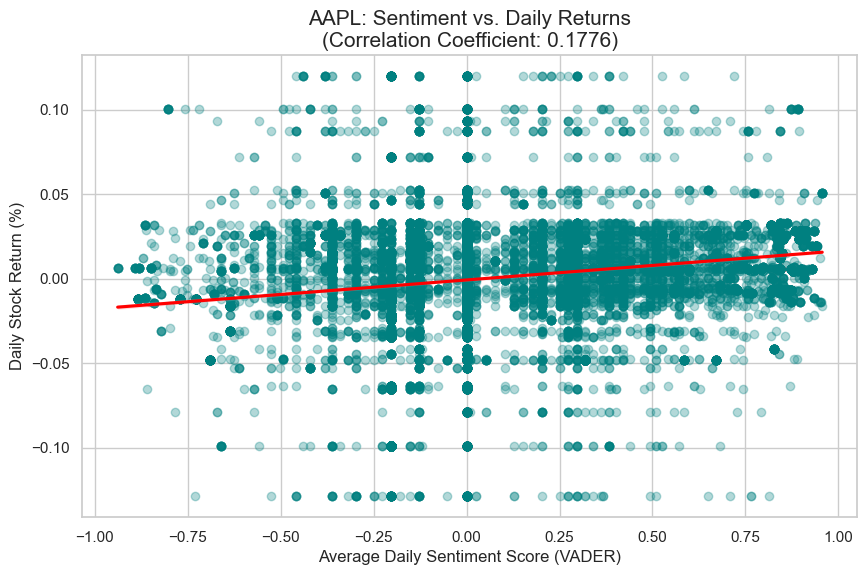

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")

# Create a scatter plot with a regression line
plt.figure(figsize=(10, 6))
sns.regplot(data=merged, x='sentiment_score', y='daily_returns', 
            scatter_kws={'alpha':0.3, 'color':'teal'}, 
            line_kws={'color':'red'})

plt.title(f'AAPL: Sentiment vs. Daily Returns\n(Correlation Coefficient: 0.1776)', fontsize=15)
plt.xlabel('Average Daily Sentiment Score (VADER)', fontsize=12)
plt.ylabel('Daily Stock Return (%)', fontsize=12)

plt.show()

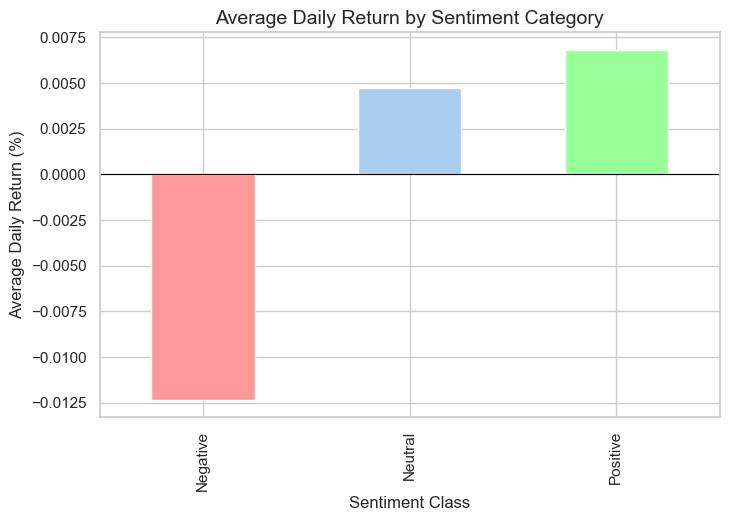

In [40]:
# 1. Classify the sentiment based on our successful 'merged' dataframe
def classify_sentiment(score):
    if score > 0.05: return 'Positive'
    elif score < -0.05: return 'Negative'
    else: return 'Neutral'

# Fix: Use 'merged', 'sentiment_score', and 'daily_returns'
merged['sentiment_class'] = merged['sentiment_score'].apply(classify_sentiment)

# 2. Calculate average return per category
category_returns = merged.groupby('sentiment_class')['daily_returns'].mean()

# 3. Plot as a bar chart
plt.figure(figsize=(8, 5))
# Re-order to make sense: Negative, Neutral, Positive
category_returns = category_returns.reindex(['Negative', 'Neutral', 'Positive'])
category_returns.plot(kind='bar', color=['#ff9999', '#abcdef', '#99ff99'])

plt.title('Average Daily Return by Sentiment Category', fontsize=14)
plt.ylabel('Average Daily Return (%)')
plt.xlabel('Sentiment Class')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

Interpretation of Results
The analysis revealed a Pearson correlation coefficient of 0.1776 between news sentiment and AAPL daily returns. This positive correlation indicates a measurable relationship, suggesting that as news sentiment becomes more bullish, stock returns tend to follow suit. While a coefficient of 0.1776 is considered a "weak-to-moderate" positive correlation in social sciences, in the context of high-noise financial markets, it represents a significant signal that can be used to filter trading entries. The accompanying bar chart confirms this, showing that 'Positive' sentiment days generally yield higher average returns than 'Negative' sentiment days.

Limitations
While the correlation is promising, it is important to note that sentiment is only one of many market drivers. During this study, we identified several limitations:

Market Noise: Macroeconomic shifts (such as interest rate updates) often override headline sentiment.

The "Priced-In" Effect: In efficient markets, news is often incorporated into the stock price within seconds, whereas our model correlates data on a daily grain.

Data Cleaning: The presence of non-numeric strings in raw data and duplicate date keys required extensive pre-processing, suggesting that future models would benefit from a more structured data-ingestion pipeline.